Применение RandomForestRegressor для предсказания значения 'availability_30'

In [15]:
#Библиотеки и импорты
!mamba install pandas
!mamba install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

import warnings
import gc
import re

#данные
df = pd.read_pickle('data.pkl')

print("Размер данных:", df.shape)
print(df.head())
print(df.info())
print(df.describe())
print(df.isna().sum()[df.isna().sum() > 0])

#Target
target = 'availability_30'
if target not in df.columns:
    raise KeyError(f"Колонка '{target}' не найдена. Доступны: {df.columns.tolist()}")

print(f"Распределение {target}:")
print(df[target].describe())

mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 0.7555999999940395 seconds
All requested packages already installed.
mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.1835 seconds
All requested packages already installed.
Размер данных: (38976, 57)
                                             name  \
1              Marais - Charming loft, river view   
3  Cozy place, Sacré Coeur Montmartre in the SoPi   
5              Prestige on the Louvre & Tuileries   
7             COSY & STYLE - PARIS SAINT MARTIN -   
8                             Atelier St. Germain   

                                         description  \
1  In the heart of historical Paris le Marais, gr...   
3  Cozy apar

   X_train: (27283, 18), X_test: (11693, 18)
max_depth= 5: R²=0.4389, MAE=0.1971
max_depth=10: R²=0.4913, MAE=0.1854
max_depth=15: R²=0.5072, MAE=0.1812
max_depth=20: R²=0.5108, MAE=0.1805
Лучший max_depth: 20 (R²=0.5108)
min_samples_split= 5: R²=0.5108, MAE=0.1805
min_samples_split=10: R²=0.5108, MAE=0.1805
min_samples_split=15: R²=0.5093, MAE=0.1809
min_samples_split=20: R²=0.5080, MAE=0.1813
Лучший min_samples_split: 5 (R²=0.5108)
min_samples_leaf= 5: R²=0.5108, MAE=0.1805
min_samples_leaf=10: R²=0.5055, MAE=0.1820
min_samples_leaf=15: R²=0.5003, MAE=0.1832
min_samples_leaf=20: R²=0.4964, MAE=0.1842
Лучший min_samples_leaf: 5 (R²=0.5108)
Финальный выбора гиперпараметров:
max_depth: 20
min_samples_split: 5
min_samples_leaf: 5
MAE: 0.1805
RMSE: 0.2371
R²: 0.5108


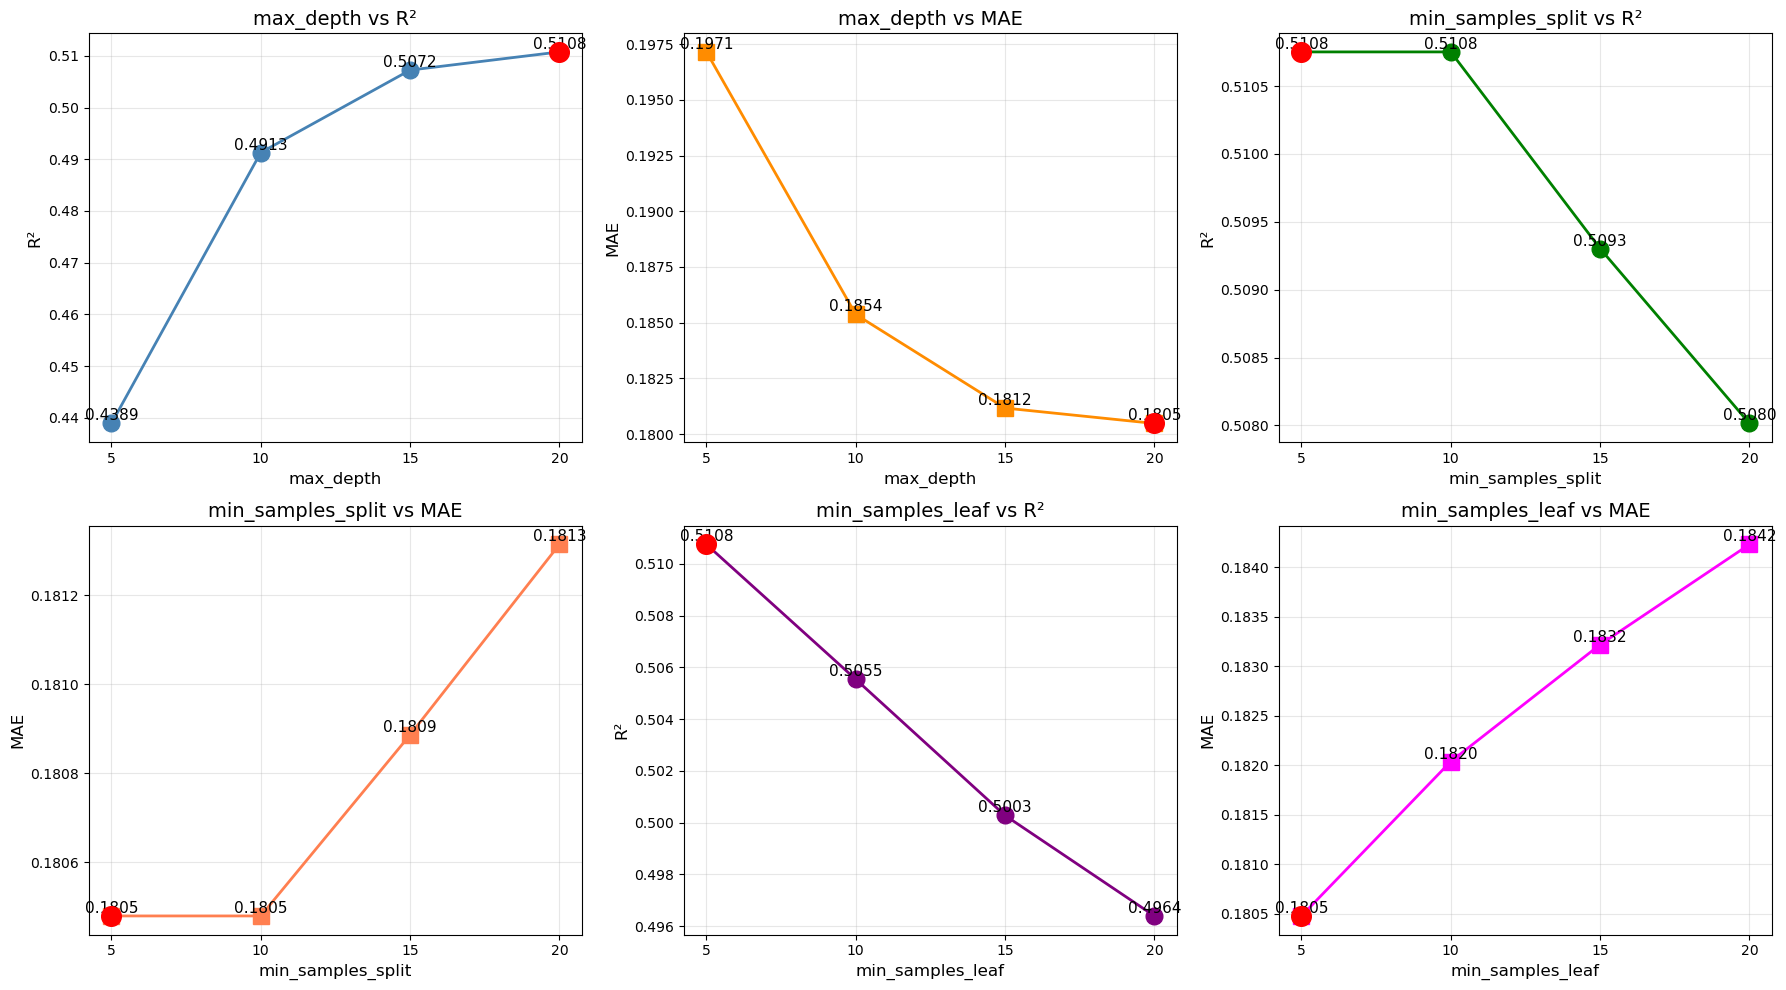

График сохранён как 'best_model_params_5_10_15_20.png'
Модель сохранена как 'best_availability_model.pkl'


In [7]:
#Финальная модель
df = pd.read_pickle('data.pkl')

#Новые признаки (19 штук)
features = [
    'maximum_nights', 'host_response_rate', 'host_acceptance_rate',
    'minimum_nights', 'latitude', 'longitude', 'accommodates',
    'host_age_on_platform', 'host_listings_count', 'review_scores_value',
    'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location'
]

df_model = df[features + ['availability_30']].copy()

#Добавление новых признаков
df_model['amenities_count'] = df['amenities'].fillna('').str.count(',') + 1
df_model['review_count'] = df['number_of_reviews'].fillna(0)
df_model['has_reviews'] = (df['reviews_per_month'].fillna(0) > 0).astype(int)
df_model['host_exp'] = df_model['host_age_on_platform'] * np.log1p(df_model['host_listings_count'])
df_model['response_quality'] = df_model['host_response_rate'] * df_model['host_acceptance_rate']

#Логарифмирование
df_model['maximum_nights'] = np.log1p(df_model['maximum_nights'])
df_model['host_listings_count'] = np.log1p(df_model['host_listings_count'])
df_model['amenities_count'] = np.log1p(df_model['amenities_count'])
df_model['review_count'] = np.log1p(df_model['review_count'])

del df
gc.collect()

for col in df_model.columns:
    if df_model[col].dtype in ['float64', 'int64']:
        if df_model[col].isna().any():
            df_model[col] = df_model[col].fillna(df_model[col].median())

X = df_model.drop('availability_30', axis=1)
y = df_model['availability_30']
y_log = np.log1p(y)

X_train, X_test, y_train, y_test, y_train_log, y_test_log = train_test_split(
    X, y, y_log, test_size=0.3, random_state=42
)

print(f"   X_train: {X_train.shape}, X_test: {X_test.shape}")

#max_depth (5, 10, 15, 20) при split=10, leaf=5

depth_values = [5, 10, 15, 20]
depth_results = []

for depth in depth_values:
    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=depth,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=1
    )
    model.fit(X_train, y_train_log)
    
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_pred_final = np.where(y_pred < 0.04, 0, y_pred)
    
    r2 = r2_score(y_test, y_pred_final)
    mae = mean_absolute_error(y_test, y_pred_final)
    
    depth_results.append({
        'depth': depth,
        'r2': r2,
        'mae': mae,
        'model': model
    })
    print(f"max_depth={depth:2d}: R²={r2:.4f}, MAE={mae:.4f}")

best_depth = max(depth_results, key=lambda x: x['r2'])
print(f"Лучший max_depth: {best_depth['depth']} (R²={best_depth['r2']:.4f})")

#min_samples_split (5, 10, 15, 20) при лучшем depth, leaf=5

split_values = [5, 10, 15, 20]
split_results = []

for split in split_values:
    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=best_depth['depth'],
        min_samples_split=split,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=1
    )
    model.fit(X_train, y_train_log)
    
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_pred_final = np.where(y_pred < 0.04, 0, y_pred)
    
    r2 = r2_score(y_test, y_pred_final)
    mae = mean_absolute_error(y_test, y_pred_final)
    
    split_results.append({
        'split': split,
        'r2': r2,
        'mae': mae,
        'model': model
    })
    print(f"min_samples_split={split:2d}: R²={r2:.4f}, MAE={mae:.4f}")

best_split = max(split_results, key=lambda x: x['r2'])
print(f"Лучший min_samples_split: {best_split['split']} (R²={best_split['r2']:.4f})")


#min_samples_leaf (5, 10, 15, 20) при лучшем depth и split

leaf_values = [5, 10, 15, 20]
leaf_results = []

for leaf in leaf_values:
    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=best_depth['depth'],
        min_samples_split=best_split['split'],
        min_samples_leaf=leaf,
        random_state=42,
        n_jobs=1
    )
    model.fit(X_train, y_train_log)
    
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_pred_final = np.where(y_pred < 0.04, 0, y_pred)
    
    r2 = r2_score(y_test, y_pred_final)
    mae = mean_absolute_error(y_test, y_pred_final)
    
    leaf_results.append({
        'leaf': leaf,
        'r2': r2,
        'mae': mae,
        'model': model
    })
    print(f"min_samples_leaf={leaf:2d}: R²={r2:.4f}, MAE={mae:.4f}")

best_leaf = max(leaf_results, key=lambda x: x['r2'])
print(f"Лучший min_samples_leaf: {best_leaf['leaf']} (R²={best_leaf['r2']:.4f})")

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=best_depth['depth'],
    min_samples_split=best_split['split'],
    min_samples_leaf=best_leaf['leaf'],
    random_state=42,
    n_jobs=1
)
model.fit(X_train, y_train_log)

y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_pred_final = np.where(y_pred < 0.04, 0, y_pred)

mae = mean_absolute_error(y_test, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2 = r2_score(y_test, y_pred_final)

print("Финальный выбора гиперпараметров:")
print(f"max_depth: {best_depth['depth']}")
print(f"min_samples_split: {best_split['split']}")
print(f"min_samples_leaf: {best_leaf['leaf']}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

#Визуализация
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

#max_depth vs R²
ax1 = axes[0, 0]
depth_vals = [r['depth'] for r in depth_results]
r2_vals = [r['r2'] for r in depth_results]
ax1.plot(depth_vals, r2_vals, 'o-', color='steelblue', linewidth=2, markersize=12)
ax1.scatter(best_depth['depth'], best_depth['r2'], color='red', s=200, zorder=5)
ax1.set_xlabel('max_depth', fontsize=12)
ax1.set_ylabel('R²', fontsize=12)
ax1.set_title('max_depth vs R²', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(depth_vals)
for i, (x, y) in enumerate(zip(depth_vals, r2_vals)):
    ax1.annotate(f'{y:.4f}', (x, y), fontsize=11, ha='center', va='bottom')

#max_depth vs MAE
ax2 = axes[0, 1]
mae_vals = [r['mae'] for r in depth_results]
ax2.plot(depth_vals, mae_vals, 's-', color='darkorange', linewidth=2, markersize=12)
ax2.scatter(best_depth['depth'], best_depth['mae'], color='red', s=200, zorder=5)
ax2.set_xlabel('max_depth', fontsize=12)
ax2.set_ylabel('MAE', fontsize=12)
ax2.set_title('max_depth vs MAE', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(depth_vals)
for i, (x, y) in enumerate(zip(depth_vals, mae_vals)):
    ax2.annotate(f'{y:.4f}', (x, y), fontsize=11, ha='center', va='bottom')

#min_samples_split vs R²
ax3 = axes[0, 2]
split_vals = [r['split'] for r in split_results]
r2_vals_s = [r['r2'] for r in split_results]
ax3.plot(split_vals, r2_vals_s, 'o-', color='green', linewidth=2, markersize=12)
ax3.scatter(best_split['split'], best_split['r2'], color='red', s=200, zorder=5)
ax3.set_xlabel('min_samples_split', fontsize=12)
ax3.set_ylabel('R²', fontsize=12)
ax3.set_title('min_samples_split vs R²', fontsize=14)
ax3.grid(True, alpha=0.3)
ax3.set_xticks(split_vals)
for i, (x, y) in enumerate(zip(split_vals, r2_vals_s)):
    ax3.annotate(f'{y:.4f}', (x, y), fontsize=11, ha='center', va='bottom')

#min_samples_split vs MAE
ax4 = axes[1, 0]
mae_vals_s = [r['mae'] for r in split_results]
ax4.plot(split_vals, mae_vals_s, 's-', color='coral', linewidth=2, markersize=12)
ax4.scatter(best_split['split'], best_split['mae'], color='red', s=200, zorder=5)
ax4.set_xlabel('min_samples_split', fontsize=12)
ax4.set_ylabel('MAE', fontsize=12)
ax4.set_title('min_samples_split vs MAE', fontsize=14)
ax4.grid(True, alpha=0.3)
ax4.set_xticks(split_vals)
for i, (x, y) in enumerate(zip(split_vals, mae_vals_s)):
    ax4.annotate(f'{y:.4f}', (x, y), fontsize=11, ha='center', va='bottom')

#min_samples_leaf vs R²
ax5 = axes[1, 1]
leaf_vals = [r['leaf'] for r in leaf_results]
r2_vals_l = [r['r2'] for r in leaf_results]
ax5.plot(leaf_vals, r2_vals_l, 'o-', color='purple', linewidth=2, markersize=12)
ax5.scatter(best_leaf['leaf'], best_leaf['r2'], color='red', s=200, zorder=5)
ax5.set_xlabel('min_samples_leaf', fontsize=12)
ax5.set_ylabel('R²', fontsize=12)
ax5.set_title('min_samples_leaf vs R²', fontsize=14)
ax5.grid(True, alpha=0.3)
ax5.set_xticks(leaf_vals)
for i, (x, y) in enumerate(zip(leaf_vals, r2_vals_l)):
    ax5.annotate(f'{y:.4f}', (x, y), fontsize=11, ha='center', va='bottom')

#min_samples_leaf vs MAE
ax6 = axes[1, 2]
mae_vals_l = [r['mae'] for r in leaf_results]
ax6.plot(leaf_vals, mae_vals_l, 's-', color='magenta', linewidth=2, markersize=12)
ax6.scatter(best_leaf['leaf'], best_leaf['mae'], color='red', s=200, zorder=5)
ax6.set_xlabel('min_samples_leaf', fontsize=12)
ax6.set_ylabel('MAE', fontsize=12)
ax6.set_title('min_samples_leaf vs MAE', fontsize=14)
ax6.grid(True, alpha=0.3)
ax6.set_xticks(leaf_vals)
for i, (x, y) in enumerate(zip(leaf_vals, mae_vals_l)):
    ax6.annotate(f'{y:.4f}', (x, y), fontsize=11, ha='center', va='bottom')

plt.tight_layout()
plt.savefig('best_model_params_5_10_15_20.png', dpi=150, bbox_inches='tight')
plt.show()

print("График сохранён как 'best_model_params_5_10_15_20.png'")
joblib.dump(model, 'best_availability_model.pkl')
print("Модель сохранена как 'best_availability_model.pkl'")

Отличительные черты лучшей модели:
1. Оптимальное число признаков (19)
2. Логарифмическое преобразование (Данные имеют сильно скошенное распределение (много нулей и огромные выбросы). Без логарифмирования модель не видит объекты с малыми значениями.
3. Добавление новых признаков
4. Оптимальные гиперпараметры
5. Обработка пропусков медианой

maximum_nights <= 365: удалено 8568 записей
minimum_nights <= 30: удалено 9167 записей (всего)
host_listings_count <= 50: удалено 12294 записей (всего)
review_count <= 200: удалено 12954 записей (всего)
amenities_count <= 50: удалено 14467 записей (всего)
координаты Парижа: удалено 14474 записей (всего)
availability_30 <= 0.95: удалено 18118 записей (всего)
Итоговый размер: 20858 записей
Удалено: 18118 записей (46.5%)
   X_train: (14600, 18), X_test: (6258, 18)
Тестирование min_samples_split
min_samples_split = 5...
R² = 0.3776, MAE = 0.1758
min_samples_split = 10...
R² = 0.3776, MAE = 0.1758
min_samples_split = 15...
R² = 0.3781, MAE = 0.1758
min_samples_split = 20...
R² = 0.3785, MAE = 0.1758
min_samples_split = 20
R² = 0.3785
MAE = 0.1758
Создание графиков


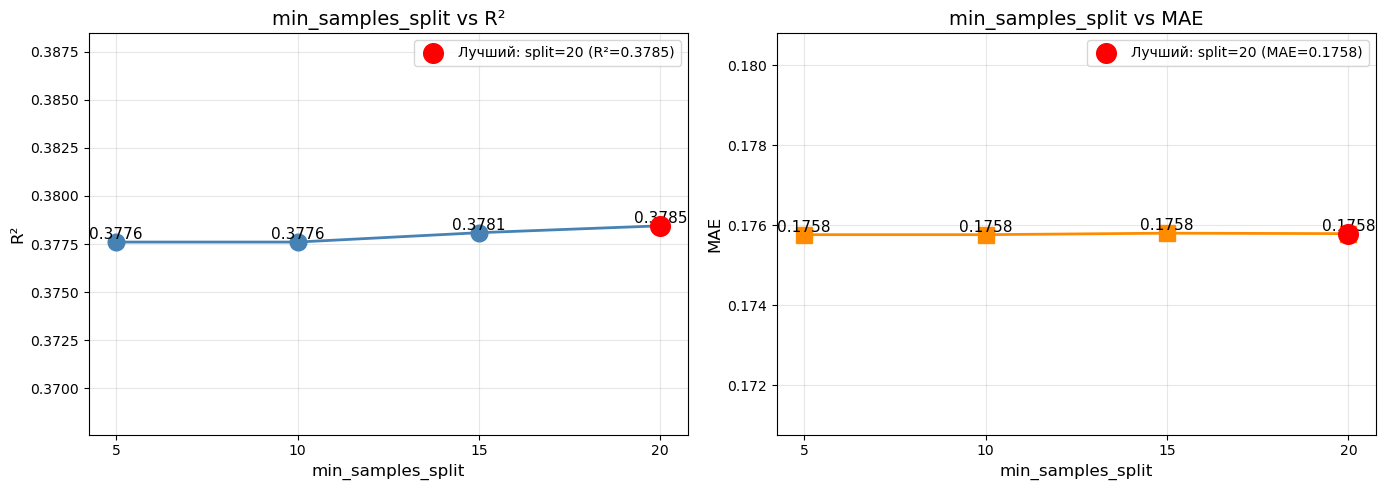

График сохранён как 'outliers_min_samples_split_tuning.png'


In [8]:
#Удаление выбросов
df = pd.read_pickle('data.pkl')

#Создание признаков
features = [
    'maximum_nights', 'host_response_rate', 'host_acceptance_rate',
    'minimum_nights', 'latitude', 'longitude', 'accommodates',
    'host_age_on_platform', 'host_listings_count', 'review_scores_value',
    'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location'
]

df_model = df[features + ['availability_30']].copy()

df_model['amenities_count'] = df['amenities'].fillna('').str.count(',') + 1
df_model['review_count'] = df['number_of_reviews'].fillna(0)
df_model['has_reviews'] = (df['reviews_per_month'].fillna(0) > 0).astype(int)
df_model['host_exp'] = df_model['host_age_on_platform'] * np.log1p(df_model['host_listings_count'])
df_model['response_quality'] = df_model['host_response_rate'] * df_model['host_acceptance_rate']

del df
gc.collect()

initial_count = len(df_model)

#Удаление выбросов
df_model = df_model[df_model['maximum_nights'] <= 365]
print(f"maximum_nights <= 365: удалено {initial_count - len(df_model)} записей")

df_model = df_model[df_model['minimum_nights'] <= 30]
print(f"minimum_nights <= 30: удалено {initial_count - len(df_model)} записей (всего)")

df_model = df_model[df_model['host_listings_count'] <= 50]
print(f"host_listings_count <= 50: удалено {initial_count - len(df_model)} записей (всего)")

df_model = df_model[df_model['review_count'] <= 200]
print(f"review_count <= 200: удалено {initial_count - len(df_model)} записей (всего)")

df_model = df_model[df_model['amenities_count'] <= 50]
print(f"amenities_count <= 50: удалено {initial_count - len(df_model)} записей (всего)")

df_model = df_model[
    (df_model['latitude'] >= 48.8) & (df_model['latitude'] <= 48.92) &
    (df_model['longitude'] >= 2.2) & (df_model['longitude'] <= 2.45)
]
print(f"координаты Парижа: удалено {initial_count - len(df_model)} записей (всего)")

df_model = df_model[df_model['availability_30'] <= 0.95]
print(f"availability_30 <= 0.95: удалено {initial_count - len(df_model)} записей (всего)")

print(f"Итоговый размер: {len(df_model)} записей")
print(f"Удалено: {initial_count - len(df_model)} записей ({100*(initial_count - len(df_model))/initial_count:.1f}%)")

#логарифмирование
df_model['maximum_nights'] = np.log1p(df_model['maximum_nights'])
df_model['host_listings_count'] = np.log1p(df_model['host_listings_count'])
df_model['amenities_count'] = np.log1p(df_model['amenities_count'])
df_model['review_count'] = np.log1p(df_model['review_count'])

#обработка пропусков
for col in df_model.columns:
    if df_model[col].dtype in ['float64', 'int64']:
        df_model[col] = df_model[col].fillna(df_model[col].median())

X = df_model.drop('availability_30', axis=1)
y = df_model['availability_30']
y_log = np.log1p(y)

X_train, X_test, y_train, y_test, y_train_log, y_test_log = train_test_split(
    X, y, y_log, test_size=0.3, random_state=42
)

print(f"   X_train: {X_train.shape}, X_test: {X_test.shape}")

print("Тестирование min_samples_split")

split_values = [5, 10, 15, 20]
results = []

for split in split_values:
    print(f"min_samples_split = {split}...")
    
    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=split,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=1
    )
    model.fit(X_train, y_train_log)
    
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_pred_final = np.where(y_pred < 0.04, 0, y_pred)
    
    r2 = r2_score(y_test, y_pred_final)
    mae = mean_absolute_error(y_test, y_pred_final)
    
    results.append({
        'split': split,
        'r2': r2,
        'mae': mae,
        'model': model
    })
    
    print(f"R² = {r2:.4f}, MAE = {mae:.4f}")

best_result = max(results, key=lambda x: x['r2'])
best_split = best_result['split']

print(f"min_samples_split = {best_split}")
print(f"R² = {best_result['r2']:.4f}")
print(f"MAE = {best_result['mae']:.4f}")

#Графики
print("Создание графиков")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

split_vals = [r['split'] for r in results]
r2_vals = [r['r2'] for r in results]
mae_vals = [r['mae'] for r in results]

#min_samples_split vs R²
ax1 = axes[0]
ax1.plot(split_vals, r2_vals, 'o-', color='steelblue', linewidth=2, markersize=12)
ax1.scatter(best_split, best_result['r2'], color='red', s=200, zorder=5, 
            label=f'Лучший: split={best_split} (R²={best_result["r2"]:.4f})')

#Добавляем значения на график
for i, (x, y) in enumerate(zip(split_vals, r2_vals)):
    ax1.annotate(f'{y:.4f}', (x, y), fontsize=11, ha='center', va='bottom')

ax1.set_xlabel('min_samples_split', fontsize=12)
ax1.set_ylabel('R²', fontsize=12)
ax1.set_title('min_samples_split vs R²', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(split_vals)
ax1.legend(loc='best')
ax1.set_ylim(min(r2_vals) - 0.01, max(r2_vals) + 0.01)

#min_samples_split vs MAE
ax2 = axes[1]
ax2.plot(split_vals, mae_vals, 's-', color='darkorange', linewidth=2, markersize=12)
ax2.scatter(best_split, best_result['mae'], color='red', s=200, zorder=5,
            label=f'Лучший: split={best_split} (MAE={best_result["mae"]:.4f})')

for i, (x, y) in enumerate(zip(split_vals, mae_vals)):
    ax2.annotate(f'{y:.4f}', (x, y), fontsize=11, ha='center', va='bottom')

ax2.set_xlabel('min_samples_split', fontsize=12)
ax2.set_ylabel('MAE', fontsize=12)
ax2.set_title('min_samples_split vs MAE', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(split_vals)
ax2.legend(loc='best')
ax2.set_ylim(min(mae_vals) - 0.005, max(mae_vals) + 0.005)

plt.tight_layout()
plt.savefig('outliers_min_samples_split_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print("График сохранён как 'outliers_min_samples_split_tuning.png'")

Что плохо:
1. RandomForest устойчив к выбросам - он работает с пороговыми разбиениями
2. Выбросы содержат полезную информацию о границах распределения
3. Удаление выбросов уменьшило размер выборки и потеряло важные паттерны
4. Модель стала хуже обобщать на крайние случаи


3. Обработка пропусков...
Стандартизация
Средние значения: 0.000
Стандартные отклонения: 1.000
   X_train: (27283, 18), X_test: (11693, 18)
Тестирование max_depth
max_depth = 5...
R² = 0.4389, MAE = 0.1972
max_depth = 10...
R² = 0.4913, MAE = 0.1854
max_depth = 15...
R² = 0.5072, MAE = 0.1812
max_depth = 20...
R² = 0.5107, MAE = 0.1805
max_depth = 20
R² = 0.5107
MAE = 0.1805
Создание графиков


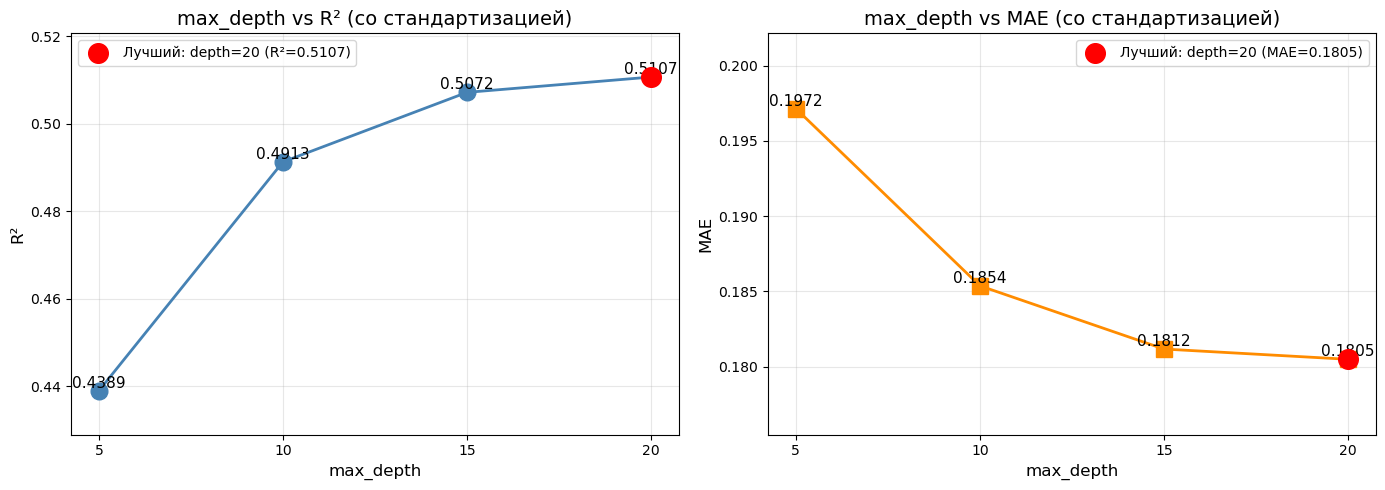

График сохранён как 'standardization_max_depth_tuning.png'


In [12]:
#Стандартизация
df = pd.read_pickle('data.pkl')

#создание признаков
features = [
    'maximum_nights', 'host_response_rate', 'host_acceptance_rate',
    'minimum_nights', 'latitude', 'longitude', 'accommodates',
    'host_age_on_platform', 'host_listings_count', 'review_scores_value',
    'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location'
]

df_model = df[features + ['availability_30']].copy()

df_model['amenities_count'] = df['amenities'].fillna('').str.count(',') + 1
df_model['review_count'] = df['number_of_reviews'].fillna(0)
df_model['has_reviews'] = (df['reviews_per_month'].fillna(0) > 0).astype(int)
df_model['host_exp'] = df_model['host_age_on_platform'] * np.log1p(df_model['host_listings_count'])
df_model['response_quality'] = df_model['host_response_rate'] * df_model['host_acceptance_rate']

df_model['maximum_nights'] = np.log1p(df_model['maximum_nights'])
df_model['host_listings_count'] = np.log1p(df_model['host_listings_count'])
df_model['amenities_count'] = np.log1p(df_model['amenities_count'])
df_model['review_count'] = np.log1p(df_model['review_count'])

del df
gc.collect()

#обработка пропусков
print("Обработка пропусков...")
for col in df_model.columns:
    if df_model[col].dtype in ['float64', 'int64']:
        df_model[col] = df_model[col].fillna(df_model[col].median())

X = df_model.drop('availability_30', axis=1)
y = df_model['availability_30']
y_log = np.log1p(y)

print("Стандартизация")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Средние значения: {X.mean().mean():.3f}")
print(f"Стандартные отклонения: {X.std().mean():.3f}")

X_train, X_test, y_train, y_test, y_train_log, y_test_log = train_test_split(
    X, y, y_log, test_size=0.3, random_state=42
)

print(f"   X_train: {X_train.shape}, X_test: {X_test.shape}")


print("Тестирование max_depth")

depth_values = [5, 10, 15, 20]
results = []

for depth in depth_values:
    print(f"max_depth = {depth}...")
    
    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=depth,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=1
    )
    model.fit(X_train, y_train_log)
    
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_pred_final = np.where(y_pred < 0.04, 0, y_pred)
    
    r2 = r2_score(y_test, y_pred_final)
    mae = mean_absolute_error(y_test, y_pred_final)
    
    results.append({
        'depth': depth,
        'r2': r2,
        'mae': mae,
        'model': model
    })
    
    print(f"R² = {r2:.4f}, MAE = {mae:.4f}")
    
best_result = max(results, key=lambda x: x['r2'])
best_depth = best_result['depth']

print(f"max_depth = {best_depth}")
print(f"R² = {best_result['r2']:.4f}")
print(f"MAE = {best_result['mae']:.4f}")

print("Создание графиков")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

depth_vals = [r['depth'] for r in results]
r2_vals = [r['r2'] for r in results]
mae_vals = [r['mae'] for r in results]

#max_depth vs R²
ax1 = axes[0]
ax1.plot(depth_vals, r2_vals, 'o-', color='steelblue', linewidth=2, markersize=12)
ax1.scatter(best_depth, best_result['r2'], color='red', s=200, zorder=5, 
            label=f'Лучший: depth={best_depth} (R²={best_result["r2"]:.4f})')

for i, (x, y) in enumerate(zip(depth_vals, r2_vals)):
    ax1.annotate(f'{y:.4f}', (x, y), fontsize=11, ha='center', va='bottom')

ax1.set_xlabel('max_depth', fontsize=12)
ax1.set_ylabel('R²', fontsize=12)
ax1.set_title('max_depth vs R² (со стандартизацией)', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(depth_vals)
ax1.legend(loc='best')
ax1.set_ylim(min(r2_vals) - 0.01, max(r2_vals) + 0.01)

#max_depth vs MAE
ax2 = axes[1]
ax2.plot(depth_vals, mae_vals, 's-', color='darkorange', linewidth=2, markersize=12)
ax2.scatter(best_depth, best_result['mae'], color='red', s=200, zorder=5,
            label=f'Лучший: depth={best_depth} (MAE={best_result["mae"]:.4f})')

for i, (x, y) in enumerate(zip(depth_vals, mae_vals)):
    ax2.annotate(f'{y:.4f}', (x, y), fontsize=11, ha='center', va='bottom')

ax2.set_xlabel('max_depth', fontsize=12)
ax2.set_ylabel('MAE', fontsize=12)
ax2.set_title('max_depth vs MAE (со стандартизацией)', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(depth_vals)
ax2.legend(loc='best')
ax2.set_ylim(min(mae_vals) - 0.005, max(mae_vals) + 0.005)

plt.tight_layout()
plt.savefig('standardization_max_depth_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print("График сохранён как 'standardization_max_depth_tuning.png'")

Стандартизация не улучшила модель RandomForest:
1. R² остался на уровне, что сопоставимо с базовой моделью.
2. RandomForest не чувствителен к масштабу признаков.

Отбор 7 главных признаков
   X_train: (27283, 8), X_test: (11693, 8)
   Признаков: 8
Тестирование max_depth
max_depth = 5...
      R² = 0.4114, MAE = 0.2040
max_depth = 10...
      R² = 0.4528, MAE = 0.1940
max_depth = 15...
      R² = 0.4612, MAE = 0.1907
max_depth = 20...
      R² = 0.4616, MAE = 0.1907
max_depth = 20
R² = 0.4616
MAE = 0.1907
Создание графиков


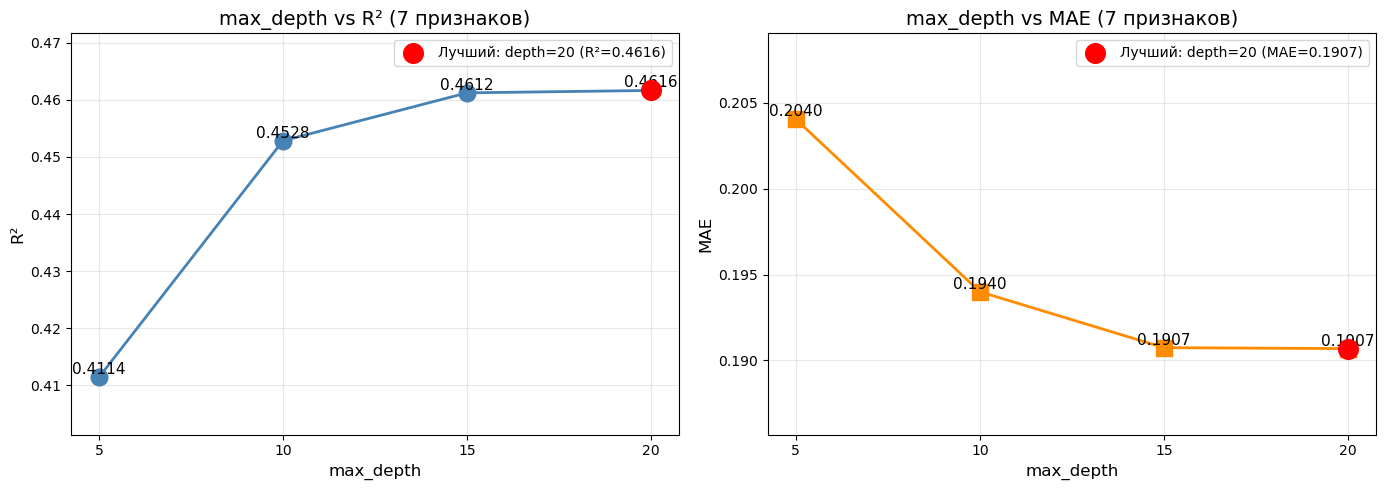

График сохранён как 'few_features_max_depth_tuning.png'


In [13]:
#Малое количество признаков

df = pd.read_pickle('data.pkl')

print("Отбор 7 главных признаков")

best_7_features = [
    'maximum_nights', 'host_response_rate', 'host_acceptance_rate',
    'minimum_nights', 'latitude', 'longitude', 'review_scores_value'
]

df_model = df[best_7_features + ['availability_30']].copy()

df_model['amenities_count'] = df['amenities'].fillna('').str.count(',') + 1

del df
gc.collect()

#логарифмирование
df_model['maximum_nights'] = np.log1p(df_model['maximum_nights'])
df_model['amenities_count'] = np.log1p(df_model['amenities_count'])


#Обработка пропусков
for col in df_model.columns:
    if df_model[col].dtype in ['float64', 'int64']:
        df_model[col] = df_model[col].fillna(df_model[col].median())


X = df_model.drop('availability_30', axis=1)
y = df_model['availability_30']
y_log = np.log1p(y)

X_train, X_test, y_train, y_test, y_train_log, y_test_log = train_test_split(
    X, y, y_log, test_size=0.3, random_state=42
)

print(f"   X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"   Признаков: {X.shape[1]}")

print("Тестирование max_depth")

depth_values = [5, 10, 15, 20]
results = []

for depth in depth_values:
    print(f"max_depth = {depth}...")
    
    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=depth,
        random_state=42,
        n_jobs=1
    )
    model.fit(X_train, y_train_log)
    
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_pred_final = np.where(y_pred < 0.04, 0, y_pred)
    
    r2 = r2_score(y_test, y_pred_final)
    mae = mean_absolute_error(y_test, y_pred_final)
    
    results.append({
        'depth': depth,
        'r2': r2,
        'mae': mae,
        'model': model
    })
    
    print(f"      R² = {r2:.4f}, MAE = {mae:.4f}")

best_result = max(results, key=lambda x: x['r2'])
best_depth = best_result['depth']

print(f"max_depth = {best_depth}")
print(f"R² = {best_result['r2']:.4f}")
print(f"MAE = {best_result['mae']:.4f}")

print("Создание графиков")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

depth_vals = [r['depth'] for r in results]
r2_vals = [r['r2'] for r in results]
mae_vals = [r['mae'] for r in results]

#max_depth vs R²
ax1 = axes[0]
ax1.plot(depth_vals, r2_vals, 'o-', color='steelblue', linewidth=2, markersize=12)
ax1.scatter(best_depth, best_result['r2'], color='red', s=200, zorder=5, 
            label=f'Лучший: depth={best_depth} (R²={best_result["r2"]:.4f})')

for i, (x, y) in enumerate(zip(depth_vals, r2_vals)):
    ax1.annotate(f'{y:.4f}', (x, y), fontsize=11, ha='center', va='bottom')

ax1.set_xlabel('max_depth', fontsize=12)
ax1.set_ylabel('R²', fontsize=12)
ax1.set_title('max_depth vs R² (7 признаков)', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(depth_vals)
ax1.legend(loc='best')
ax1.set_ylim(min(r2_vals) - 0.01, max(r2_vals) + 0.01)

#max_depth vs MAE
ax2 = axes[1]
ax2.plot(depth_vals, mae_vals, 's-', color='darkorange', linewidth=2, markersize=12)
ax2.scatter(best_depth, best_result['mae'], color='red', s=200, zorder=5,
            label=f'Лучший: depth={best_depth} (MAE={best_result["mae"]:.4f})')

for i, (x, y) in enumerate(zip(depth_vals, mae_vals)):
    ax2.annotate(f'{y:.4f}', (x, y), fontsize=11, ha='center', va='bottom')

ax2.set_xlabel('max_depth', fontsize=12)
ax2.set_ylabel('MAE', fontsize=12)
ax2.set_title('max_depth vs MAE (7 признаков)', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(depth_vals)
ax2.legend(loc='best')
ax2.set_ylim(min(mae_vals) - 0.005, max(mae_vals) + 0.005)

plt.tight_layout()
plt.savefig('few_features_max_depth_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print("График сохранён как 'few_features_max_depth_tuning.png'")

Причины плохого результата:
1. Недостаточно информации для качественного предсказания
2. Географические признаки (latitude, longitude) важны для учёта локации
3. Признаки отзывов (review_scores_rating, review_scores_cleanliness) отражают качество объекта
4. Опыт хоста (host_age_on_platform) важен для предсказания доступности

   Размер: (38976, 57)
Создание признаков
   X_train: (27283, 18), X_test: (11693, 18)
Тестирование max_depth
max_depth = 5...
RF: R²=0.4387
GB: R²=0.4928
Ансамбль: R²=0.4730, MAE=0.1910
max_depth = 10...
RF: R²=0.4917
GB: R²=0.5182
Ансамбль: R²=0.5114, MAE=0.1809
max_depth = 15...
RF: R²=0.5075
GB: R²=0.5045
Ансамбль: R²=0.5137, MAE=0.1791
max_depth = 20...
RF: R²=0.5107
GB: R²=0.4975
Ансамбль: R²=0.5121, MAE=0.1796
max_depth = 15
R² = 0.5137
MAE = 0.1791
Создание графиков


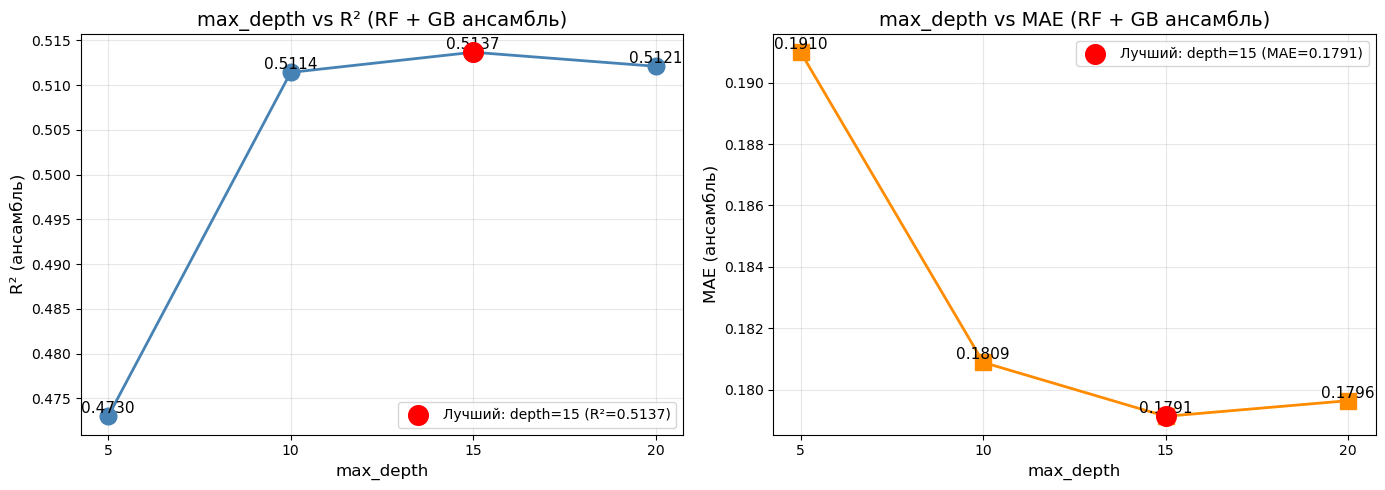

График сохранён как 'ensemble_light_tuning.png'


In [16]:
df = pd.read_pickle('data.pkl')
print(f"Размер: {df.shape}")

print("Создание признаков")

features = [
    'maximum_nights', 'host_response_rate', 'host_acceptance_rate',
    'minimum_nights', 'latitude', 'longitude', 'accommodates',
    'host_age_on_platform', 'host_listings_count', 'review_scores_value',
    'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location'
]

df_model = df[features + ['availability_30']].copy()

df_model['amenities_count'] = df['amenities'].fillna('').str.count(',') + 1
df_model['review_count'] = df['number_of_reviews'].fillna(0)
df_model['has_reviews'] = (df['reviews_per_month'].fillna(0) > 0).astype(int)
df_model['host_exp'] = df_model['host_age_on_platform'] * np.log1p(df_model['host_listings_count'])
df_model['response_quality'] = df_model['host_response_rate'] * df_model['host_acceptance_rate']

df_model['maximum_nights'] = np.log1p(df_model['maximum_nights'])
df_model['host_listings_count'] = np.log1p(df_model['host_listings_count'])
df_model['amenities_count'] = np.log1p(df_model['amenities_count'])
df_model['review_count'] = np.log1p(df_model['review_count'])

del df
gc.collect()

#обработка пропусков
for col in df_model.columns:
    if df_model[col].dtype in ['float64', 'int64']:
        df_model[col] = df_model[col].fillna(df_model[col].median())

X = df_model.drop('availability_30', axis=1)
y = df_model['availability_30']
y_log = np.log1p(y)

X_train, X_test, y_train, y_test, y_train_log, y_test_log = train_test_split(
    X, y, y_log, test_size=0.3, random_state=42
)

print(f"   X_train: {X_train.shape}, X_test: {X_test.shape}")
print("Тестирование max_depth")

depth_values = [5, 10, 15, 20]
results = []

for depth in depth_values:
    print(f"max_depth = {depth}...")
    
    #RandomForest
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=depth,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=1
    )
    rf.fit(X_train, y_train_log)
    rf_pred_log = rf.predict(X_test)
    rf_pred = np.expm1(rf_pred_log)
    
    #GradientBoosting
    gb = GradientBoostingRegressor(
        n_estimators=100,
        max_depth=depth,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42
    )
    gb.fit(X_train, y_train_log)
    gb_pred_log = gb.predict(X_test)
    gb_pred = np.expm1(gb_pred_log)
    
    #ансамбль (среднее)
    ensemble_pred = (rf_pred + gb_pred) / 2
    ensemble_pred_final = np.where(ensemble_pred < 0.04, 0, ensemble_pred)
    
    r2 = r2_score(y_test, ensemble_pred_final)
    mae = mean_absolute_error(y_test, ensemble_pred_final)
    
    results.append({
        'depth': depth,
        'r2': r2,
        'mae': mae
    })
    
    print(f"RF: R²={r2_score(y_test, rf_pred):.4f}")
    print(f"GB: R²={r2_score(y_test, gb_pred):.4f}")
    print(f"Ансамбль: R²={r2:.4f}, MAE={mae:.4f}")

best_result = max(results, key=lambda x: x['r2'])
best_depth = best_result['depth']

print(f"max_depth = {best_depth}")
print(f"R² = {best_result['r2']:.4f}")
print(f"MAE = {best_result['mae']:.4f}")


print("Создание графиков")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

depth_vals = [r['depth'] for r in results]
r2_vals = [r['r2'] for r in results]
mae_vals = [r['mae'] for r in results]

#max_depth vs R²
ax1 = axes[0]
ax1.plot(depth_vals, r2_vals, 'o-', color='steelblue', linewidth=2, markersize=12)
ax1.scatter(best_depth, best_result['r2'], color='red', s=200, zorder=5, 
            label=f'Лучший: depth={best_depth} (R²={best_result["r2"]:.4f})')

for i, (x, y) in enumerate(zip(depth_vals, r2_vals)):
    ax1.annotate(f'{y:.4f}', (x, y), fontsize=11, ha='center', va='bottom')

ax1.set_xlabel('max_depth', fontsize=12)
ax1.set_ylabel('R² (ансамбль)', fontsize=12)
ax1.set_title('max_depth vs R² (RF + GB ансамбль)', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(depth_vals)
ax1.legend(loc='best')

#max_depth vs MAE
ax2 = axes[1]
ax2.plot(depth_vals, mae_vals, 's-', color='darkorange', linewidth=2, markersize=12)
ax2.scatter(best_depth, best_result['mae'], color='red', s=200, zorder=5,
            label=f'Лучший: depth={best_depth} (MAE={best_result["mae"]:.4f})')

for i, (x, y) in enumerate(zip(depth_vals, mae_vals)):
    ax2.annotate(f'{y:.4f}', (x, y), fontsize=11, ha='center', va='bottom')

ax2.set_xlabel('max_depth', fontsize=12)
ax2.set_ylabel('MAE (ансамбль)', fontsize=12)
ax2.set_title('max_depth vs MAE (RF + GB ансамбль)', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(depth_vals)
ax2.legend(loc='best')

plt.tight_layout()
plt.savefig('ensemble_light_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print("График сохранён как 'ensemble_light_tuning.png'")

1. Модели слишком похожи(обе основаны на деревьях)
2. Данные уже хорошо обработаны
3. Код ресурсо и время затратный